**Lab 3: Spectral Representation**

The goal of this lab is to gain familiarity with the spectral representations of signals, specially the spectrograms.

In [ ]:
!git clone https://github.com/maat2006/sis1_group1.git  

In [ ]:
import os
import numpy as np
import librosa
import IPython.display as ipd
import matplotlib.pyplot as plt
from scipy import signal
from IPython.display import Audio

from sis1_group1.util import load_audio, plot_signals, plot_spectrogram, plot_mean_spectrogram, plot_spectrum_at

First upload your reference signal and plot the first seconds of it.

In [ ]:
# Write the code here
##!git clone https://github.com/maat2006/sis1_group1.git  
filepath ="./sis1_group1/audio/Harp.wav"
#filepath = "C:\\Users\\usuario\\Documents\\GitHub\\sis1_group1\\Harp.wav"
ref, fs = load_audio(filepath)
audafrequency= 690.00
audaperiod= 1/audafrequency
startpoint= 0.25 #We choose a point that doesn't belongs to the attack section
endpoint= startpoint+ 9*audaperiod      #We want three periods
plot_signals(ref,fs, startpoint, endpoint)

# **Exercises**

**1. Spectrograms**

A spectrogram is obtained by estimating the frequency content in short sections of the signal. The magnitude of the spectrum over individual sections is plotted as intensity or color on a two-dimensional plot versus frequency and time. The length of each section, or window length, determines the frequency resolution. Longer windows give good frequency resolution but fail to
track frequency changes well. Shorter windows have poor frequency resolution, but good tracking.

In Python the function `spectrogram` from the `scipy.signal` package will
compute the spectrogram. A common call to the function is defined as follows. No need to understand the meaning of each parameter at this stage. Note that we provide the `plot_spectrogram` function to plot the spectrogram.

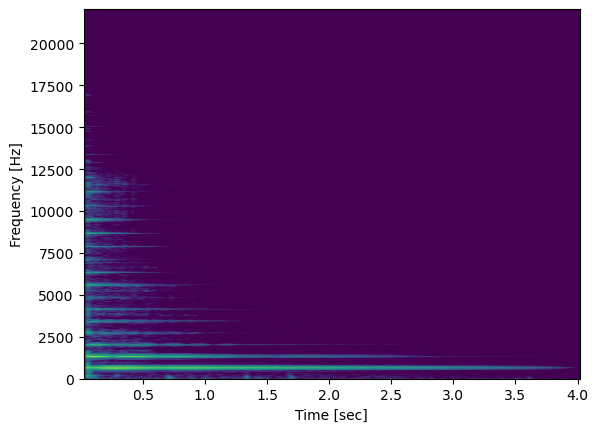

In [ ]:
ff, tt, S= signal.spectrogram(ref,fs=fs, nperseg=2048, noverlap=1024)
plot_spectrogram(ff, tt,S)

We can plot the spectrum (one slice of the spectrogram) of the signal at an specific time using the `plot_spectrum_at` function. For instance, we can see the spectrum of the signal at the 0.5 seconds:

In [43]:
plot_spectrum_at(ff, tt, S, 0.5)

1.1. Calculate and plot the spectrogram of your reference signal. Use `plt.ylim` to select the limits of the y axis in order to zoom in the frequency region of interest. For instance if you want to see the region between 0 and 4000 Hz, you can call `plt.ylim([0, 4000])` after the `plot_spectrogram` function.


(0.0, 4000.0)

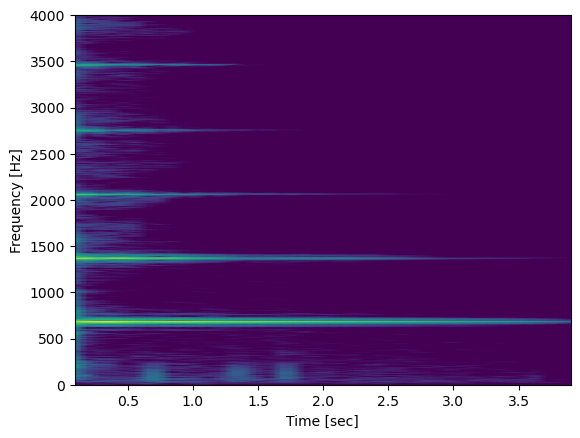

In [ ]:
# Write the code here
windows_len = 8192              #A bigger one to represent the stable part
ff, tt, S_ref= signal.spectrogram(ref,44100, nperseg=windows_len, noverlap=windows_len/2)   #We use the function
plot_spectrogram(ff, tt,S_ref)          #We plot it
plt.ylim([0,4000])

1.2. Select a time where almost all harmonics are present and plot the spectrum at that time.

In [ ]:
# Write the code here
plot_spectrum_at(ff, tt, S_ref, 0.25)

1.3. Use the cursor for measuring the weights of the fundamental frequency and some harmonics (6-10)

In [ ]:
weights = [1,0.2952121,0.04313676,0.0218036, 0.0259182, 0.024076,0.00309,0.04765, 0.01077,0.003986,0.00294] # We use the graph

**2. Synthesis**:

Let's define a function to synthetize an harmonic singal which receives the fundamental frequency ($f_0$) and the weights ($A_k$) of each harmonic and the time vector ($t$). This is similar to what you did in Lab 3- Ex3.2.


In [ ]:
def synthesize(f0, phi, Ak, t,A):
  y = 0
  for k in range(len(Ak)):
    y+= Ak[k] * np.cos(2*np.pi*f0*t*k+ k*phi-(k-1)*np.pi/2)     #The formula of the previous lab
  y= A*y/np.amax((y))     #Finally, we normalize the amplitude applying the formula, previous lab
  return y

2.1. Use the `synthetize` function to generate a synthesis with the weights ($A_k$) found in 1.3 and the fundamental frequency and phases found in previous labs. Plot both the reference and the synthetize signal. Listen to the synthetize signal.

In [57]:
# Write the code here
A = 0.25155567                      ##It's the amplitude of the reference signal
phi = 49*np.pi/72  #previous lab
t = np.arange(0, 4, 1.0/fs)
synthetizesignal= synthesize(690, phi, weights, t, A )
plot_signals([ref,synthetizesignal],fs, startpoint, endpoint, name=["reference", "synthesized"])

2.2. Calculate the spectrogram of the synthesized signal `S_synt`; and compare the spectrums of both signals at the same time using `plot_spectrum_at(ff, tt, [S_ref, S_synt], time)`, where `S_ref`is spectrogram of the reference signal.

**Note:** use the same window length to calculate both spectrograms.

In [ ]:
# Write the code here
windows_len = 8192
ff, tt, S_synt= signal.spectrogram(synthetizesignal,44100, nperseg=windows_len, noverlap=windows_len/2)
plot_spectrum_at(ff, tt, [S_ref, S_synt], 0.25,)        #We plot it

2.3. Compare the spectrograms of the two signals. What are the main differences?

First, we need to know that the orange one is the synthesized one and the blue one is the reference. We can see that in the fundamental frequency and the first harmonics, both graphs are similar. However, when we continue, we see that the synthesized one doesn't have more peaks and decays. These happen because it doesn't have enough weights for representing all frequencies.

2.4. Listen to the two audios (reference and synthesized). What are the main differences?

In [62]:
# Write the code here
Audio(synthetizesignal, rate=fs)

In [64]:
Audio(ref, rate=fs)

One of the main differences is that in the synthesized signal we don't have all the harmonics.  We lose naturalness, and we have a less complex timbre. The main differences between both audios are that the synthesized one sounds more robotic and doesn't sound as much like a plucked string as the harp one does. This difference happens because we are not able to replicate it perfectly. We can't recreate the changes of frequency made by the external factors of the record, such as the wind sound or others. Moreover, we have to notice that the real sound has an attack section, which makes it more realistic.